In [1]:
# =====================
# TensorFlow / GPU
# =====================
import os
import tensorflow as tf

gpus = tf.config.list_physical_devices("GPU")
if gpus:
    print("GPU available:", gpus)
else:
    print("No GPU, using CPU")

if os.getenv("CUDA_VISIBLE_DEVICES") is None:
    gpu_num = 0  # 使用 CPU 可设为 ""
    os.environ["CUDA_VISIBLE_DEVICES"] = f"{gpu_num}"

os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"


# =====================
# Scientific stack
# =====================
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial.transform import Rotation as R

%matplotlib inline


# =====================
# Mitsuba / DrJit
# =====================
import mitsuba as mi
import drjit as dr


# =====================
# Sionna RT
# =====================
from sionna.rt import (
    load_scene,
    PlanarArray,
    Transmitter,
    Receiver,
    Camera,
    PathSolver,
    ITURadioMaterial,
    SceneObject,
    AntennaPattern,
    register_antenna_pattern,
)


# =====================
# Custom utils / scenes
# =====================
import sionnautils
from sionnautils.custom_scene import list_scenes, get_scene


# =====================
# Project-specific
# =====================
from Engine_V3 import Engine


# =====================
# Misc
# =====================
import json
from pathlib import Path
import yaml


2026-01-24 05:17:19.970457: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-01-24 05:17:20.018377: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-01-24 05:17:21.279478: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]



Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
Users of this version of Gym should be able to simply replace 'import gym' with 'import gymnasium as gym' in the vast majority of cases.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


In [2]:
import yaml


def normalize_config(obj):
    """Recursively normalize:
    - numeric strings (incl. scientific notation) -> float
    - 'np.pi', 'np.e', 'np.inf' -> numpy constants
    """
    if isinstance(obj, dict):
        return {k: normalize_config(v) for k, v in obj.items()}

    if isinstance(obj, list):
        return [normalize_config(v) for v in obj]

    if isinstance(obj, str):
        s = obj.strip()

        # numpy constants
        if s == "np.pi":
            return np.pi
        if s == "np.e":
            return np.e
        if s in ("np.inf", "inf"):
            return np.inf
        if s in ("-np.inf", "-inf"):
            return -np.inf

        # numeric strings (supports "15.0e9", "200.0e6", "3.5E9", etc.)
        try:
            return float(s)
        except ValueError:
            return obj  # keep as string if not numeric

    return obj  # int/float/bool/None stay as-is


with open("config_CM_TX1.yaml", "r") as f:
    cfg = yaml.safe_load(f)

cfg = normalize_config(cfg)


In [3]:
from sionnautils.custom_scene import list_scenes, get_scene
scenes = list_scenes()
print(scenes)

scene_path, map_data = get_scene('nyu_tandon')
for k, v in map_data.items():
    print(f'{k}: {v}')

# scene = load_scene(scene_path,merge_shapes=True)
scene = load_scene(scene_path,merge_shapes=True)

floor = scene.get('ground')
# print(f'Floor material: {floor.radio_material.name}')
floor.radio_material = ITURadioMaterial("itu_concrete",
                                "concrete",
                                thickness=0.01,
                                color=(0.5, 0.5, 0.5))

scene.remove("itu_wet_ground")

for name, obj in scene.objects.items():
    print(f'{name:<15}{obj.radio_material.name}')
# scene.render(camera=my_cam, num_samples=512)

scene.radio_materials

['nyu_tandon']
bbox_lat: [40.69012764197041, 40.699120858029595]
bbox_long: [-73.99156687083165, -73.97970552916836]
address: 5 MetroTech Center, Brooklyn, NY 11201
descr: NYU Tandon campus
2026-01-24 05:17:24 WARN  [HDRFilm] Monochrome mode enabled, setting film output pixel format to 'luminance' (was rgb).
no-name-1      itu_marble
ground         itu_concrete


{'itu_marble': ITURadioMaterial type=marble
                  eta_r=7.074
                  sigma=0.018
                  thickness=0.100
                  scattering_coefficient=0.000
                  xpd_coefficient=0.000,
 'itu_concrete': ITURadioMaterial type=concrete
                  eta_r=5.240
                  sigma=0.123
                  thickness=0.010
                  scattering_coefficient=0.000
                  xpd_coefficient=0.000}

In [4]:
engine = Engine(cfg, scene)


In [5]:

def is_inside_building_mitsuba(scene, point, direction=np.array([0, 0, 1]), max_hits=50):
   """
   Casts a ray and counts intersections to determine if point is inside a mesh.
   """
   ray_origin = mi.Point3f(point)
   ray_dir = mi.Vector3f(direction)
   ray = mi.Ray3f(o=ray_origin, d=ray_dir)


   scene_mi = scene._scene  # Internal Mitsuba scene from Sionna


   count = 0
   for _ in range(max_hits):
       si = scene_mi.ray_intersect(ray, active=dr.ones(mi.Bool, 1)[0])
       if not si.is_valid():
           break
       count += 1
       ray.o = si.p + 1e-4 * ray.d  # Offset origin to avoid repeated self-hit


   return (count % 2 == 1)


In [6]:
def generate_index_and_coordinate_map(center=(-300, 200, 1.0), grid_size=5, grid_dim=160):
   half_extent = grid_size * grid_dim / 2


   coords = np.zeros((grid_dim, grid_dim, 3))

   for i in range(grid_dim):       # row index
       for j in range(grid_dim):   # column index
           x = center[0] - half_extent + (j + 0.5) * grid_size
           y = center[1] + half_extent - (i + 0.5) * grid_size
           z = center[2]


           coords[i, j] = (x, y, z)

   return coords


In [7]:
scene = engine.scene
# scene.preview()

In [8]:
center=(-300, 200, 1)
# center=(-264.086, 68.371, 0.000)
# grid_size = 25
# grid_dim = 32
# grid_size = 50
# grid_dim = 16



grid_size = 5
grid_dim = 200

max_labels = 32


coords = generate_index_and_coordinate_map(center=center,
                                                    grid_size=grid_size,
                                                    grid_dim=grid_dim)

print(coords.shape)

half_extent = (grid_dim * grid_size) / 2
x_center, y_center = center[0], center[1]


x_coords = np.linspace(x_center - half_extent + grid_size/2,
                      x_center + half_extent - grid_size/2,
                      grid_dim)


y_coords = np.linspace(y_center + half_extent - grid_size/2,
                      y_center - half_extent + grid_size/2,
                      grid_dim)  # y is decreasing due to seaborn heatmap



(200, 200, 3)


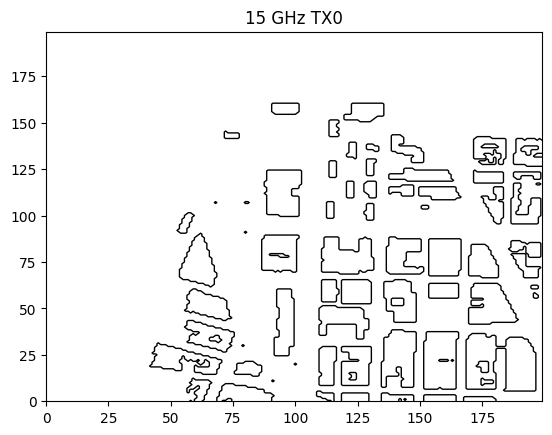

In [9]:
building_mask = np.zeros((grid_dim,grid_dim))


# for idx in range(len(indices)):
#    if is_inside_building_mitsuba(scene, coords[idx]):
#        building_mask[indices[idx,0],indices[idx,1]] = 1

for idx_x in range(grid_dim):
    for idx_y in range(grid_dim):
        if is_inside_building_mitsuba(scene, coords[idx_x, idx_y]):
            building_mask[idx_x, idx_y] = 1


flipped_mask = np.flipud(building_mask)
# Overlay mask boundary as contour (assuming mask is same shape)
plt.contour(flipped_mask, levels=[0.5], colors='black', linewidths=1)


plt.title("15 GHz TX0")
plt.show()


In [10]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import ListedColormap, BoundaryNorm

def plot_best_txrx_selection(
    capacity_map, building_mask, x_coords, y_coords, tx_loc, cfg,
    ue_id=0,
    title="Capacity Map: best (TX,RX) selection",
    figsize=(8, 7),
    alpha_mask=0.15,
):
    """
    capacity_map: (x_dim, y_dim, n_tx, n_rx)
    building_mask: (x_dim, y_dim) with 1=building
    x_coords: (x_dim,) world coords for axis-0 (rows)
    y_coords: (y_dim,) world coords for axis-1 (cols)
    tx_loc: list of [x,y,z] for each tx
    cfg: config dict with cfg["ue"]["rx_fc"]
    """

    # --------- derive dims from array (most reliable) ---------
    x_dim, y_dim, n_tx, n_rx = capacity_map.shape

    # --------- joint selection: flatten tx/rx ---------
    cap_flat  = capacity_map.reshape(x_dim, y_dim, n_tx * n_rx)   # (x,y,tx*rx)
    best_flat = np.argmax(cap_flat, axis=2)                       # (x,y) in [0..n_tx*n_rx-1]
    best_C    = np.max(cap_flat, axis=2)                          # (x,y)

    best_index = best_flat.astype(int)
    best_index[building_mask == 1] = -1
    best_index[best_C == 0] = -1

    # --------- discrete colormap (-1 + 0..K-1) ---------
    K = n_tx * n_rx

    # 预置一组颜色（够用到 K<=12）；K更大你再扩展即可
    base_colors = [
        "white",     # -1
        "#4C72B0", "#55A868", "#DD8452", "#C44E52",
        "#8172B3", "#937860", "#DA8BC3", "#8C8C8C",
        "#64B5CD", "#E17C05", "#76B7B2", "#F28E2B",
    ]
    if K + 1 > len(base_colors):
        raise ValueError(f"Need more colors: K={K} but only {len(base_colors)-1} provided")

    colors = base_colors[:K+1]  # include white + K colors
    cmap = ListedColormap(colors)

    # boundaries: [-1.5,-0.5,0.5,...,K-0.5]
    boundaries = [-1.5, -0.5] + [i + 0.5 for i in range(K)]
    norm = BoundaryNorm(boundaries, cmap.N)

    # --------- plot ---------
    fig, ax = plt.subplots(figsize=figsize)

    sns.heatmap(
        best_index,
        cmap=cmap,
        norm=norm,
        square=True,
        linewidths=0,
        cbar=True,
        cbar_kws={"shrink": 0.75},
        ax=ax
    )

    # # ticks at cell center
    # ny, nx = best_index.shape  # ny=x_dim(rows), nx=y_dim(cols)
    # ax.set_xticks(np.arange(nx) + 0.5)
    # ax.set_yticks(np.arange(ny) + 0.5)

    # # ✅ 横轴对应列(y_coords)，纵轴对应行(x_coords)
    # ax.set_xticklabels([f"{v:.0f}" for v in x_coords], rotation=90, ha="right")

    # # ✅ 关键：heatmap 顶部是 row=0，所以要让坐标“下小上大”，yticklabels 用倒序
    # ax.set_yticklabels([f"{v:.0f}" for v in y_coords], rotation=0, ha="right")
    
    
    # best_index.shape = (x_dim(rows), y_dim(cols))
    ny, nx = best_index.shape

    # 想让坐标轴最多显示多少个标签（建议 8~12）
    global max_labels

    step_x = max(1, nx // max_labels)
    step_y = max(1, ny // max_labels)

    xticks = np.arange(0, nx, step_x)
    yticks = np.arange(0, ny, step_y)

    ax.set_xticks(xticks + 0.5)
    ax.set_yticks(yticks + 0.5)
    
    ax.set_xticklabels(
        np.linspace(x_coords[0], x_coords[-1], len(xticks)).astype(int),
        rotation=90, ha="right"
    )
    ax.set_yticklabels(
        np.linspace(y_coords[0], y_coords[-1], len(yticks)).astype(int),
        rotation=0, ha="right"
    )

    # ✅ 同时把 y 轴翻过来（让数据坐标和显示坐标一致：左下为(0,0)那种直觉）
    # ax.invert_yaxis()

    # --------- overlay building mask (aligned) ---------
    ax.imshow(
        building_mask,
        origin="upper",
        extent=(0, nx, ny, 0),  # match heatmap coords
        cmap=ListedColormap(["none", "black"]),
        alpha=alpha_mask,
        interpolation="nearest",
        zorder=5
    )
    ax.contour(
        building_mask.astype(float),
        levels=[0.5],
        origin="upper",
        extent=(0, nx, ny, 0),
        colors="black",
        linewidths=1.5,
        zorder=6
    )

    # --------- plot ALL TX as big red X ---------
    for tx_id, (x0, y0, z0) in enumerate(tx_loc):
        ix = int(np.argmin(np.abs(x_coords - x0)))  # row index (axis-0)
        iy = int(np.argmin(np.abs(y_coords - y0)))  # col index (axis-1)
        ax.scatter(
            ix, iy,   # x=col, y=row
            s=220, c="red", marker="x", linewidths=3,
            zorder=50
        )


    # --------- colorbar labels: tx-id + ue-id + fc + rx-id ---------
    cbar = ax.collections[0].colorbar
    ticks = list(range(K))
    cbar.set_ticks(ticks)

    labels = []
    for k in ticks:
        tx_id = k // n_rx
        rx_id = k % n_rx
        fc_ghz = cfg["ue"]["rx_fc"][rx_id] / 1e9
        labels.append(f"tx-{tx_id} | ue-{ue_id} | {fc_ghz:.1f}GHz | rx-{rx_id}")

    cbar.set_ticklabels(labels)
    cbar.ax.tick_params(labelsize=8)
    cbar.ax.invert_yaxis()

    ax.set_title(title)
    plt.tight_layout()
    plt.show()

    return best_index  # 如果你还想拿去 debug/保存

Scanning grid:   0%|          | 0/40000 [00:00<?, ?pt/s]/workspace/ruibin/fc_project/UE_fc_hopping_v2/RT_v3/Engine_V3.py:205: RuntimeWarning: divide by zero encountered in log10
  return 10.0 * np.log10(linear_values)
Scanning grid: 100%|██████████| 40000/40000 [1:55:20<00:00,  5.78pt/s]  


[[0, 0, 0]]


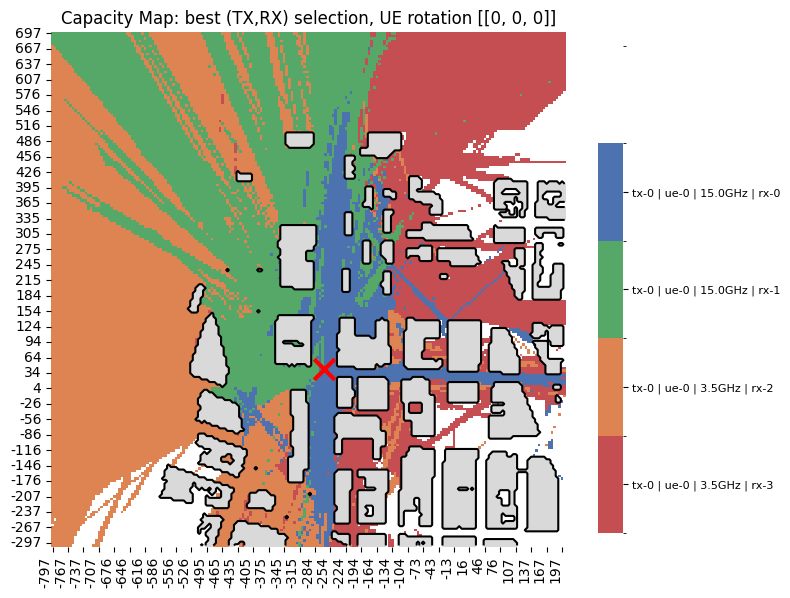

In [11]:
engine.set_ue_orientation([[0.0,0.0]])
capacity_map = engine.run_capacity_map(coords)

print(engine.ue_list[0].body.orientation)

best_index = plot_best_txrx_selection(
    capacity_map=capacity_map,
    building_mask=building_mask,
    x_coords=x_coords,
    y_coords=y_coords,
    tx_loc=engine.tx_loc,
    cfg=cfg,
    ue_id=0,
    title=f"Capacity Map: best (TX,RX) selection, UE rotation {engine.ue_list[0].body.orientation}"
)


Scanning grid:   0%|          | 0/40000 [00:00<?, ?pt/s]/workspace/ruibin/fc_project/UE_fc_hopping_v2/RT_v3/Engine_V3.py:205: RuntimeWarning: divide by zero encountered in log10
  return 10.0 * np.log10(linear_values)
Scanning grid: 100%|██████████| 40000/40000 [1:37:32<00:00,  6.83pt/s]


[[1.5708, 0, 0]]


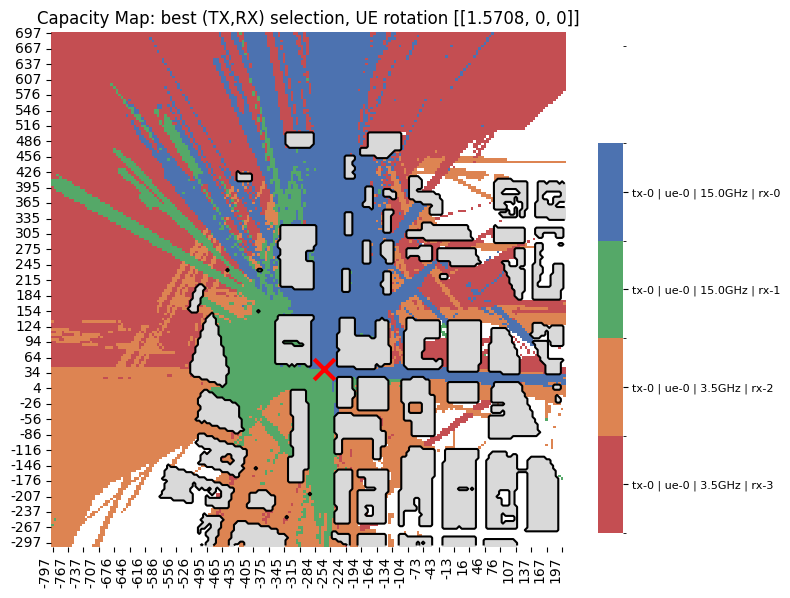

In [12]:
engine.set_ue_orientation([[90.0,0.0]])
capacity_map = engine.run_capacity_map(coords)

print(engine.ue_list[0].body.orientation)

best_index = plot_best_txrx_selection(
    capacity_map=capacity_map,
    building_mask=building_mask,
    x_coords=x_coords,
    y_coords=y_coords,
    tx_loc=engine.tx_loc,
    cfg=cfg,
    ue_id=0,
    title=f"Capacity Map: best (TX,RX) selection, UE rotation {engine.ue_list[0].body.orientation}"
)


Scanning grid:   0%|          | 0/40000 [00:00<?, ?pt/s]/workspace/ruibin/fc_project/UE_fc_hopping_v2/RT_v3/Engine_V3.py:205: RuntimeWarning: divide by zero encountered in log10
  return 10.0 * np.log10(linear_values)
Scanning grid: 100%|██████████| 40000/40000 [1:38:34<00:00,  6.76pt/s]


[[3.14159, 0, 0]]


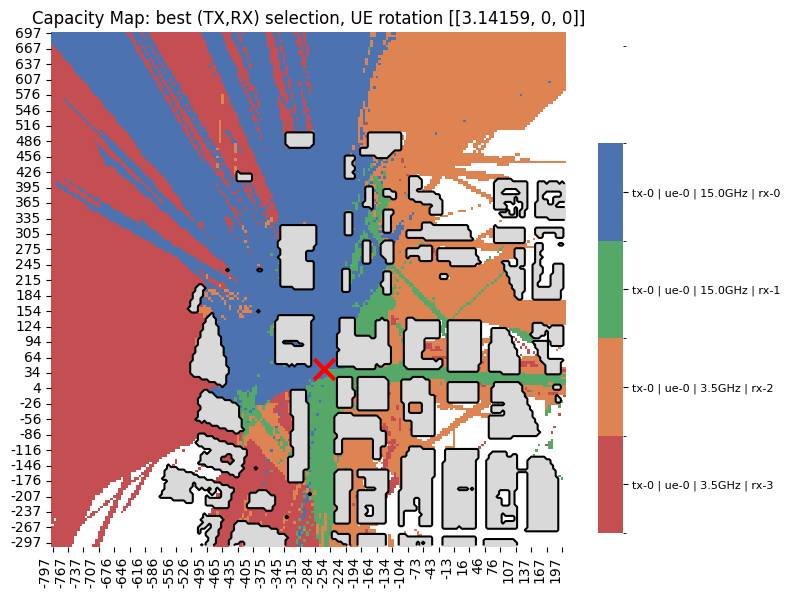

In [13]:
engine.set_ue_orientation([[180.0,0.0]])
capacity_map = engine.run_capacity_map(coords)

print(engine.ue_list[0].body.orientation)

best_index = plot_best_txrx_selection(
    capacity_map=capacity_map,
    building_mask=building_mask,
    x_coords=x_coords,
    y_coords=y_coords,
    tx_loc=engine.tx_loc,
    cfg=cfg,
    ue_id=0,
    title=f"Capacity Map: best (TX,RX) selection, UE rotation {engine.ue_list[0].body.orientation}"
)


Scanning grid:   0%|          | 0/40000 [00:00<?, ?pt/s]/workspace/ruibin/fc_project/UE_fc_hopping_v2/RT_v3/Engine_V3.py:381: UserWarning: Gimbal lock detected. Setting third angle to zero since it is not possible to uniquely determine all angles.
  self.run_RT()
Scanning grid:  20%|█▉        | 7923/40000 [19:41<1:20:42,  6.62pt/s]/workspace/ruibin/fc_project/UE_fc_hopping_v2/RT_v3/Engine_V3.py:205: RuntimeWarning: divide by zero encountered in log10
  return 10.0 * np.log10(linear_values)
Scanning grid: 100%|██████████| 40000/40000 [1:38:19<00:00,  6.78pt/s]


[[0, 1.5708, 0]]


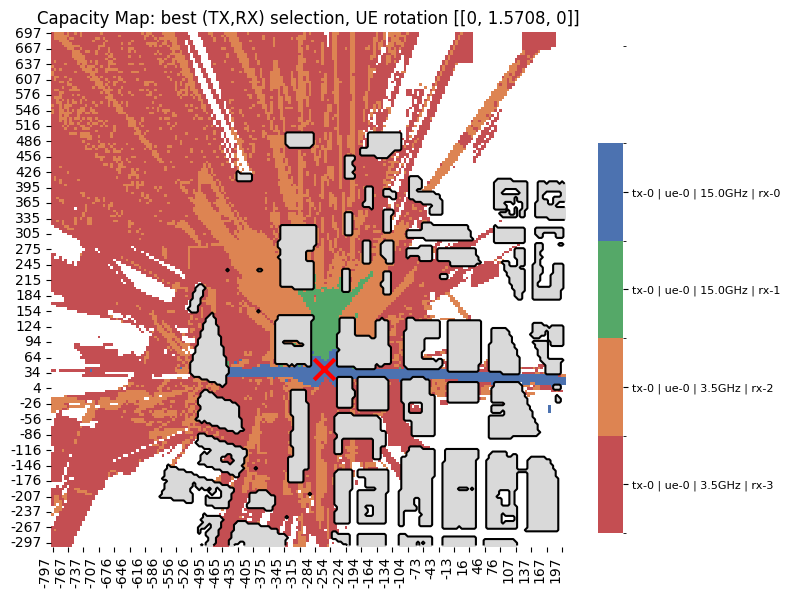

In [14]:
engine.set_ue_orientation([[0.0,90.0]])
capacity_map = engine.run_capacity_map(coords)

print(engine.ue_list[0].body.orientation)

best_index = plot_best_txrx_selection(
    capacity_map=capacity_map,
    building_mask=building_mask,
    x_coords=x_coords,
    y_coords=y_coords,
    tx_loc=engine.tx_loc,
    cfg=cfg,
    ue_id=0,
    title=f"Capacity Map: best (TX,RX) selection, UE rotation {engine.ue_list[0].body.orientation}"
)
